In [13]:
!pip install opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mohammedalrajeh/quran-recitations-for-audio-classification")

import os
import pandas as pd
import matplotlib.pyplot as plt

Skipping, found downloaded files in "./quran-recitations-for-audio-classification" (use force=True to force download)


In [14]:
import torch
from torch import nn
from torch.optim import Adam
import librosa
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import numpy as np
import os
import time
from skimage.transform import resize

device = "cuda" if torch.cuda.is_available() else "cpu"

In [15]:
data_df = pd.read_csv("/content/quran-recitations-for-audio-classification/files_paths.csv")

print(data_df["Class"].unique())
print()
print(len(data_df["Class"].unique()))

data_df.head(4)

['Mohammed_Aluhaidan' 'Yasser_Aldossary' 'Maher_Almuaiqly'
 'Nasser_Alqutami' 'AbdulBari_Althubaity' 'Bander_Balilah'
 'Ali_Alhothaify' 'Saud_Alshuraim' 'Mohammed_Ayoub' 'AbdulRahman_Alsudais'
 'Saad_Alghamdi' 'Abdullah_Albuaijan']

12


,FilePath,Class
0,./Dataset/Mohammed_Aluhaidan/lohaidan_171.wav,Mohammed_Aluhaidan
1,./Dataset/Mohammed_Aluhaidan/lohaidan_159.wav,Mohammed_Aluhaidan
2,./Dataset/Mohammed_Aluhaidan/lohaidan_401.wav,Mohammed_Aluhaidan
3,./Dataset/Mohammed_Aluhaidan/lohaidan_367.wav,Mohammed_Aluhaidan


In [16]:
data_df["FilePath"] = '/content/quran-recitations-for-audio-classification/Dataset' + data_df["FilePath"].str[1:]
data_df.head()

,FilePath,Class
0,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan
1,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan
2,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan
3,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan
4,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan


Data Shape:  (6687, 2)

Class Distribution:  Class
Saud_Alshuraim          696
Saad_Alghamdi           688
AbdulRahman_Alsudais    648
Yasser_Aldossary        576
Ali_Alhothaify          576
Bander_Balilah          576
Maher_Almuaiqly         576
Abdullah_Albuaijan      504
Mohammed_Ayoub          480
Nasser_Alqutami         456
AbdulBari_Althubaity    456
Mohammed_Aluhaidan      455
Name: count, dtype: int64



<function matplotlib.pyplot.show(close=None, block=None)>

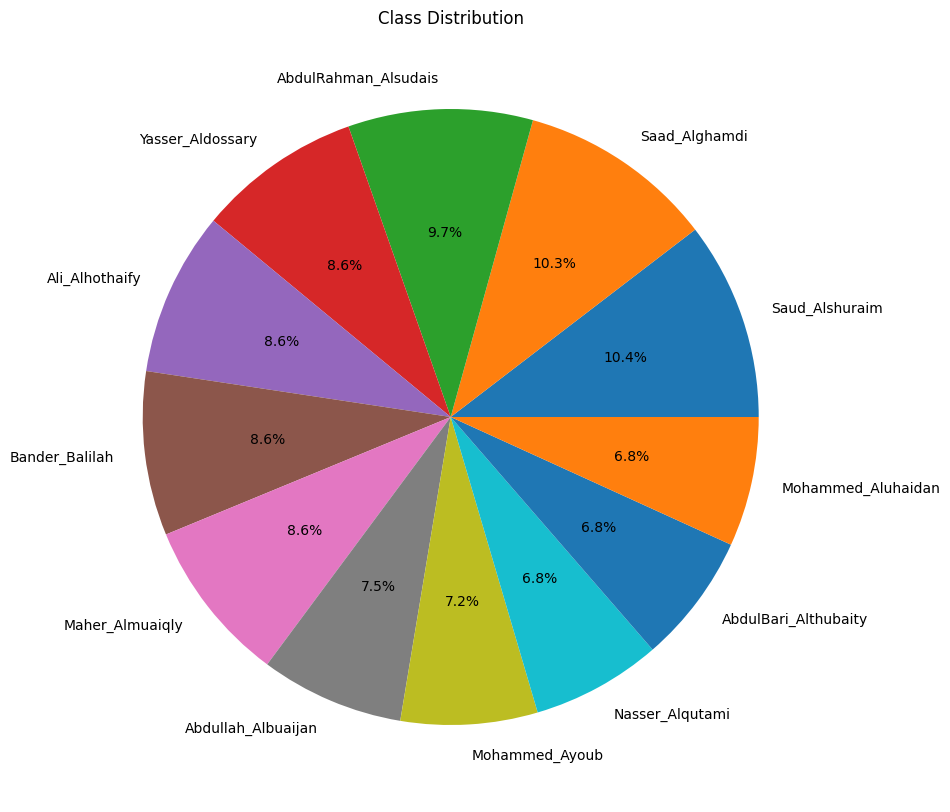

In [17]:
print("Data Shape: ", data_df.shape)
print()
print("Class Distribution: ", data_df["Class"].value_counts())

print()

plt.figure(figsize = (10, 10))

plt.pie(data_df["Class"].value_counts(), labels = data_df["Class"].value_counts().index, autopct = '%1.1f%%')

plt.title("Class Distribution")
plt.show


## **Data Split:**

We will be splitting the dataset into training, validation and testing. The following values will be split into:



*   Training: 70% (frac = 0.7, random_state = 7)
*   Validation: 15%
*   Testing: 15%






In [18]:
label_encoder = LabelEncoder()
data_df["Class"] = label_encoder.fit_transform(data_df["Class"])

train = data_df.sample(frac = 0.7, random_state = 7)
test = data_df.drop(train.index)

val = test.sample(frac = 0.5, random_state = 7)
test = test.drop(val.index) # It is essential to drop the testing data for validation.

print("Train Shape: ", train.shape)
print("Val Shape: ", val.shape)
print("Test Shape: ", test.shape)



Train Shape:  (4681, 2)
Val Shape:  (1003, 2)
Test Shape:  (1003, 2)


In [19]:
data_df

,FilePath,Class
0,/content/quran-recitations-for-audio-classific...,6
1,/content/quran-recitations-for-audio-classific...,6
2,/content/quran-recitations-for-audio-classific...,6
3,/content/quran-recitations-for-audio-classific...,6
4,/content/quran-recitations-for-audio-classific...,6
...,...,...
6682,/content/quran-recitations-for-audio-classific...,2
6683,/content/quran-recitations-for-audio-classific...,2
6684,/content/quran-recitations-for-audio-classific...,2
6685,/content/quran-recitations-for-audio-classific...,2


## **Custom Dataset Class:**

This will be created in conjunction with the preprocessing objects. We have the LabelEncoder that converts string classes to numeric as computers only understands number values.


In [42]:
class CustomAudioDataset(Dataset):
  def __init__(self, dataframe):
    self.dataframe = dataframe
    self.labels = torch.Tensor(label_encoder.fit_transform(dataframe["Class"])).type(torch.LongTensor).to(device)
    self.audio = [torch.Tensor(self.get_spectrogram(path)).type(torch.FloatTensor) for path in dataframe["FilePath"]]

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = torch.Tensor(self.labels[idx]).to(device)
    audio = (self.audio[idx].unsqueeze(0).to(device))
    return audio, label

  def get_spectrogram(self, file_path):
    sr = 23000 # Sample rate.
    duration = 6

    # Setting the size:

    img_height = 128
    img_width = 256

    signal, sr = librosa.load(file_path, sr = sr, duration = duration)
    spec = librosa.feature.melspectrogram(y = signal, sr = sr, n_fft = 2048, hop_length = 512, n_mels = 128)
    spec_db = librosa.power_to_db(spec, ref = np.max)

    spec_resized = librosa.util.fix_length(spec_db, size = (duration * sr) // 512 + 1) # DL/AI models need a constant length.
    spec_resized = resize(spec_resized, (img_height, img_width), anti_aliasing = True)
    return spec_resized



In [43]:
train_dataset = CustomAudioDataset(dataframe = train)
val_dataset = CustomAudioDataset(dataframe = val)
test_dataset = CustomAudioDataset(dataframe = test)

In [44]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 25

In [45]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = True)


In [46]:
# Building a Convolutional Neural Network:

class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(1, 16, kernel_size = 4, padding = 2)
    self.conv2 = nn.Conv2d(16, 32, kernel_size = 4, padding = 1)
    self.conv3 = nn.Conv2d(32, 64, kernel_size = 4, padding = 1)
    self.pooling = nn.MaxPool2d(2, 2)
    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()
    self.linear1 = nn.Linear((64 * 15 * 31), 4096)
    self.linear2 = nn.Linear(4096, 1024)
    self.linear3 = nn.Linear(1024, 512)
    self.output = nn.Linear(512, len(data_df['Class'].unique()))

    self.dropout = nn.Dropout(0.75)

  def forward(self, x):
    x = self.conv1(x)
    x = self.pooling(x)
    x = self.conv2(x)
    x = self.pooling(x)
    x = self.conv3(x)
    x = self.pooling(x)
    x = self.relu(x)


    x = self.flatten(x)
    x = self.linear1(x)
    x = self.dropout(x)

    x = self.linear2(x)
    x = self.dropout(x)

    x = self.linear3(x)
    x = self.dropout(x)

    x = self.output(x)

    return x

model = Net().to(device) # Create instance of model & transfer to GPU device.

print(model)


Net(
  (conv1): Conv2d(1, 16, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(16, 32, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=29760, out_features=4096, bias=True)
  (linear2): Linear(in_features=4096, out_features=1024, bias=True)
  (linear3): Linear(in_features=1024, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=12, bias=True)
  (dropout): Dropout(p=0.75, inplace=False)
)


In [47]:
from torchsummary import summary
summary(model, (1, 128, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 129, 257]             272
         MaxPool2d-2          [-1, 16, 64, 128]               0
            Conv2d-3          [-1, 32, 63, 127]           8,224
         MaxPool2d-4           [-1, 32, 31, 63]               0
            Conv2d-5           [-1, 64, 30, 62]          32,832
         MaxPool2d-6           [-1, 64, 15, 31]               0
              ReLU-7           [-1, 64, 15, 31]               0
           Flatten-8                [-1, 29760]               0
            Linear-9                 [-1, 4096]     121,901,056
          Dropout-10                 [-1, 4096]               0
           Linear-11                 [-1, 1024]       4,195,328
          Dropout-12                 [-1, 1024]               0
           Linear-13                  [-1, 512]         524,800
          Dropout-14                  [

In [48]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [54]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

import time
start_time = time.time()

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc

    optimizer.step()
    optimizer.zero_grad()

  with torch.no_grad():
    for input, labels in val_loader:
      outputs = model(input)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))

  total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__() * 100, 4))
  total_acc_validation_plot.append(round(total_acc_val/val_dataset.__len__() * 100, 4))

  print(f"Epoch: {epoch + 1}/{EPOCHS}, Train Loss: {round(total_loss_train/100, 5)}, Train Accuracy: {round(total_acc_train/train_dataset.__len__() * 100, 5)} Validation Loss: {round(total_loss_val/100, 5)}, Validation Accuracy: {round(total_acc_val, val_dataset.__len__()) * 100, 5}")
  print("=" * 40)

print("Training Time: ", round((time.time() - start_time), 5), " Seconds")






Epoch: 1/25, Train Loss: 0.3016, Train Accuracy: 97.37236 Validation Loss: 0.21565, Validation Accuracy: (93300, 5)
Epoch: 2/25, Train Loss: 0.21005, Train Accuracy: 98.14142 Validation Loss: 0.22973, Validation Accuracy: (94200, 5)
Epoch: 3/25, Train Loss: 0.26411, Train Accuracy: 97.88507 Validation Loss: 0.22148, Validation Accuracy: (94900, 5)
Epoch: 4/25, Train Loss: 0.47653, Train Accuracy: 96.06922 Validation Loss: 0.27225, Validation Accuracy: (91900, 5)
Epoch: 5/25, Train Loss: 0.22238, Train Accuracy: 97.99188 Validation Loss: 0.19835, Validation Accuracy: (94700, 5)
Epoch: 6/25, Train Loss: 0.30358, Train Accuracy: 97.5219 Validation Loss: 0.40054, Validation Accuracy: (91400, 5)
Epoch: 7/25, Train Loss: 0.34241, Train Accuracy: 97.45781 Validation Loss: 0.23658, Validation Accuracy: (94700, 5)
Epoch: 8/25, Train Loss: 0.35485, Train Accuracy: 97.07327 Validation Loss: 0.19621, Validation Accuracy: (95600, 5)
Epoch: 9/25, Train Loss: 0.3117, Train Accuracy: 97.39372 Validati

In [62]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for input, labels in test_loader:
    prediction = model(input)
    acc = (torch.argmax(prediction, axis = 1) == labels).sum().item()

    total_acc_test += acc

print(f"Total Accuracy Score: {round((total_acc_train/train_dataset.__len__() * 100), 3)} %")

Total Accuracy Score: 98.291 %


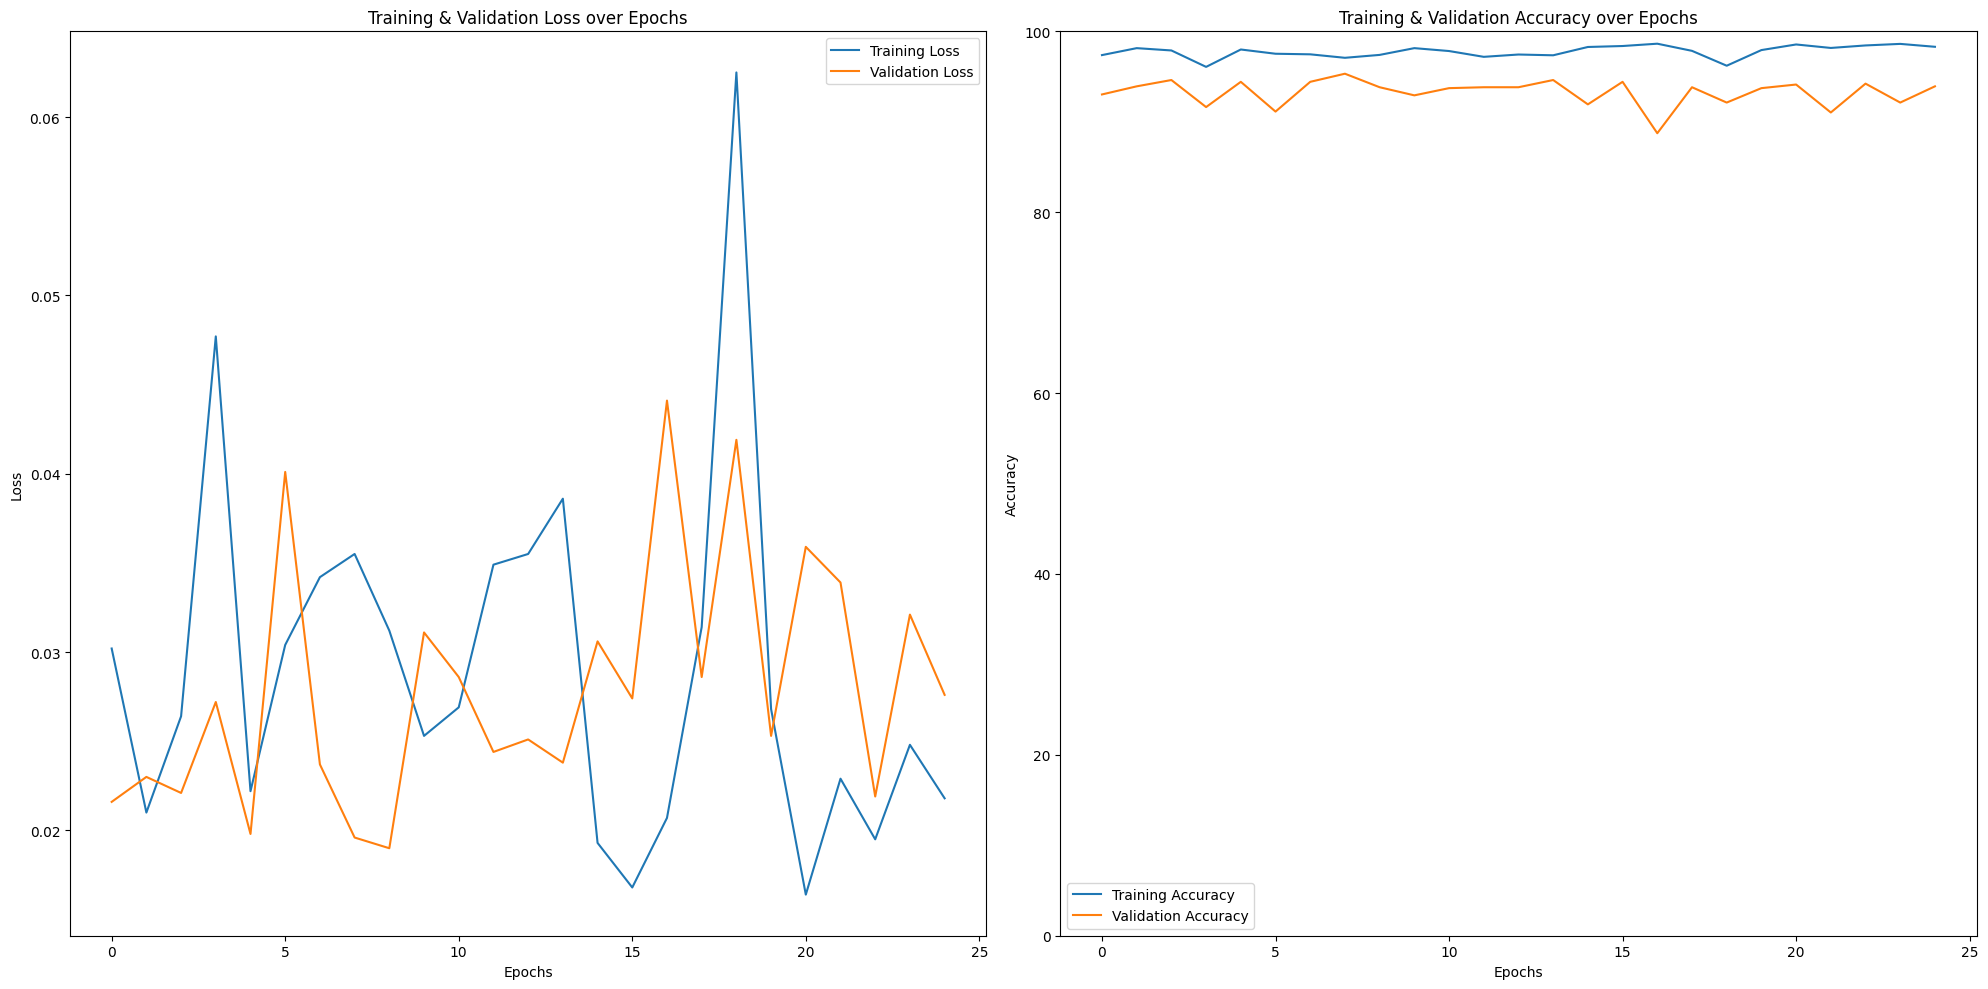

In [68]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (20, 10))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title("Training & Validation Loss over Epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title("Training & Validation Accuracy over Epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")
axs[1].set_ylim([0, 100])
axs[1].legend()

plt.tight_layout()
plt.show()


